<a href="https://www.kaggle.com/code/sonawanelalitsunil/linguistic-diversity-in-china-ml-100?scriptVersionId=268831826" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/using-linguistic-diversity-china/Using Linguistic Diversity China.csv


## Title:
Linguistic Diversity in China

## Detailed Description:
China is home to remarkable linguistic diversity, featuring hundreds of languages and dialects belonging mainly to the Sino-Tibetan, Altaic, and Indo-European families. While Mandarin Chinese (Putonghua) serves as the official language and a unifying medium of communication, numerous regional languages such as Cantonese, Shanghainese, Hokkien, Tibetan, Uyghur, and Mongolian continue to thrive within different ethnic and cultural communities. This rich tapestry of languages reflects China’s deep cultural heritage, regional identities, and historical evolution, highlighting the balance between national unity and local linguistic preservation.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/using-linguistic-diversity-china/Using Linguistic Diversity China.csv")

In [3]:
df.head()

,SAMPLE_COUNT,TRIAL_LABEL,Participant,Item,Bin,Time,Target,Competitor,Same_col_single_ani,EYE_4_P,EYE_5_P,EYE_6_P,Goal,Sentence_type,Same_col_single_ani_condion,Same_col_single_ani_cond,Sentence_type_Same
0,50,2,27,6,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_privi_foot,3: same_col_diff_ani_privi_foot,statement_same_col_diff_ani_privi_foot
1,50,2,27,6,1,0.05,0.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_privi_foot,3: same_col_diff_ani_privi_foot,statement_same_col_diff_ani_privi_foot
2,50,2,27,6,2,0.10,0.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_privi_foot,3: same_col_diff_ani_privi_foot,statement_same_col_diff_ani_privi_foot
3,50,2,27,6,3,0.15,0.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_privi_foot,3: same_col_diff_ani_privi_foot,statement_same_col_diff_ani_privi_foot
4,50,2,27,6,4,0.20,0.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_privi_foot,3: same_col_diff_ani_privi_foot,statement_same_col_diff_ani_privi_foot


In [4]:
df.tail()

,SAMPLE_COUNT,TRIAL_LABEL,Participant,Item,Bin,Time,Target,Competitor,Same_col_single_ani,EYE_4_P,EYE_5_P,EYE_6_P,Goal,Sentence_type,Same_col_single_ani_condion,Same_col_single_ani_cond,Sentence_type_Same
65530,50,8,30,1,80,4.00,1.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_block_cloth,3: same_col_diff_ani_block_cloth,statement_same_col_diff_ani_block_cloth
65531,50,8,30,1,81,4.05,1.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_block_cloth,3: same_col_diff_ani_block_cloth,statement_same_col_diff_ani_block_cloth
65532,50,8,30,1,82,4.10,1.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_block_cloth,3: same_col_diff_ani_block_cloth,statement_same_col_diff_ani_block_cloth
65533,50,8,30,1,83,4.15,1.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_block_cloth,3: same_col_diff_ani_block_cloth,statement_same_col_diff_ani_block_cloth
65534,50,8,30,1,84,4.20,1.0,0.0,0.0,0.0,0.0,0.0,known,statement,same_col_diff_ani_block_cloth,3: same_col_diff_ani_block_cloth,statement_same_col_diff_ani_block_cloth


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SAMPLE_COUNT                 65535 non-null  int64  
 1   TRIAL_LABEL                  65535 non-null  int64  
 2   Participant                  65535 non-null  int64  
 3   Item                         65535 non-null  int64  
 4   Bin                          65535 non-null  int64  
 5   Time                         65535 non-null  float64
 6   Target                       65535 non-null  float64
 7   Competitor                   65535 non-null  float64
 8   Same_col_single_ani          65535 non-null  float64
 9   EYE_4_P                      65535 non-null  float64
 10  EYE_5_P                      65535 non-null  float64
 11  EYE_6_P                      65535 non-null  float64
 12  Goal                         65535 non-null  object 
 13  Sentence_type   

In [6]:
df.describe()

,SAMPLE_COUNT,TRIAL_LABEL,Participant,Item,Bin,Time,Target,Competitor,Same_col_single_ani,EYE_4_P,EYE_5_P,EYE_6_P
count,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000,65535.000000
mean,44.167239,20.553445,30.725109,12.375143,54.483787,2.724189,0.340138,0.155707,0.092497,0.037715,0.022582,0.023411
std,11.569007,9.822296,16.779327,6.884334,31.748084,1.587404,0.461697,0.351458,0.280244,0.180177,0.138113,0.141653
min,12.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,12.000000,16.000000,6.000000,27.000000,1.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,21.000000,28.000000,12.000000,54.000000,2.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,29.000000,46.000000,18.000000,82.000000,4.100000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,50.000000,39.000000,59.000000,24.000000,109.000000,5.450000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.dtypes

SAMPLE_COUNT                     int64
TRIAL_LABEL                      int64
Participant                      int64
Item                             int64
Bin                              int64
Time                           float64
Target                         float64
Competitor                     float64
Same_col_single_ani            float64
EYE_4_P                        float64
EYE_5_P                        float64
EYE_6_P                        float64
Goal                            object
Sentence_type                   object
Same_col_single_ani_condion     object
Same_col_single_ani_cond        object
Sentence_type_Same              object
dtype: object

In [8]:
df.shape

(65535, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SAMPLE_COUNT                 65535 non-null  int64  
 1   TRIAL_LABEL                  65535 non-null  int64  
 2   Participant                  65535 non-null  int64  
 3   Item                         65535 non-null  int64  
 4   Bin                          65535 non-null  int64  
 5   Time                         65535 non-null  float64
 6   Target                       65535 non-null  float64
 7   Competitor                   65535 non-null  float64
 8   Same_col_single_ani          65535 non-null  float64
 9   EYE_4_P                      65535 non-null  float64
 10  EYE_5_P                      65535 non-null  float64
 11  EYE_6_P                      65535 non-null  float64
 12  Goal                         65535 non-null  object 
 13  Sentence_type   

In [10]:
df.isnull().sum()

SAMPLE_COUNT                   0
TRIAL_LABEL                    0
Participant                    0
Item                           0
Bin                            0
Time                           0
Target                         0
Competitor                     0
Same_col_single_ani            0
EYE_4_P                        0
EYE_5_P                        0
EYE_6_P                        0
Goal                           0
Sentence_type                  0
Same_col_single_ani_condion    0
Same_col_single_ani_cond       0
Sentence_type_Same             0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe().loc[['mean', 'max', 'min']]

,SAMPLE_COUNT,TRIAL_LABEL,Participant,Item,Bin,Time,Target,Competitor,Same_col_single_ani,EYE_4_P,EYE_5_P,EYE_6_P
mean,44.167239,20.553445,30.725109,12.375143,54.483787,2.724189,0.340138,0.155707,0.092497,0.037715,0.022582,0.023411
max,50.000000,39.000000,59.000000,24.000000,109.000000,5.450000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
min,12.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
df.columns

Index(['SAMPLE_COUNT', 'TRIAL_LABEL', 'Participant', 'Item', 'Bin', 'Time',
       'Target', 'Competitor', 'Same_col_single_ani', 'EYE_4_P', 'EYE_5_P',
       'EYE_6_P', 'Goal', 'Sentence_type', 'Same_col_single_ani_condion',
       'Same_col_single_ani_cond', 'Sentence_type_Same'],
      dtype='object')

## Data visualizations

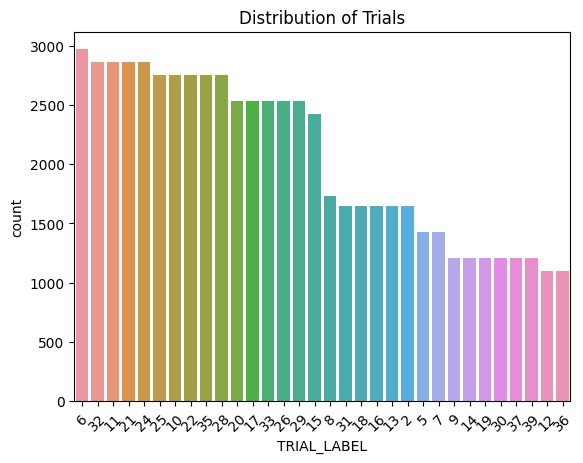

In [14]:
plt.figure()
sns.countplot(data=df, x='TRIAL_LABEL', order=df['TRIAL_LABEL'].value_counts().index)
plt.title('Distribution of Trials')
plt.xticks(rotation=45)
plt.show()

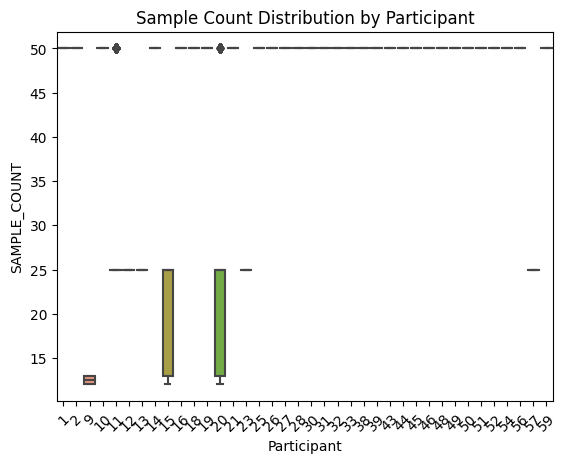

In [15]:
plt.figure()
sns.boxplot(data=df, x='Participant', y='SAMPLE_COUNT')
plt.title('Sample Count Distribution by Participant')
plt.xticks(rotation=45)
plt.show()

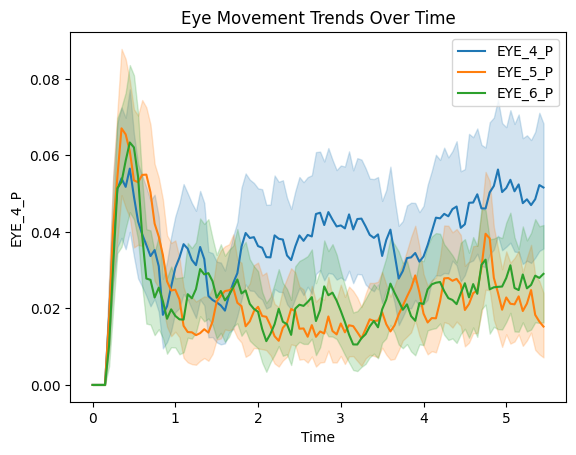

In [16]:
eye_cols = ['EYE_4_P', 'EYE_5_P', 'EYE_6_P']
plt.figure()
for col in eye_cols:
    sns.lineplot(data=df, x='Time', y=col, label=col)
plt.title('Eye Movement Trends Over Time')
plt.legend()
plt.show()

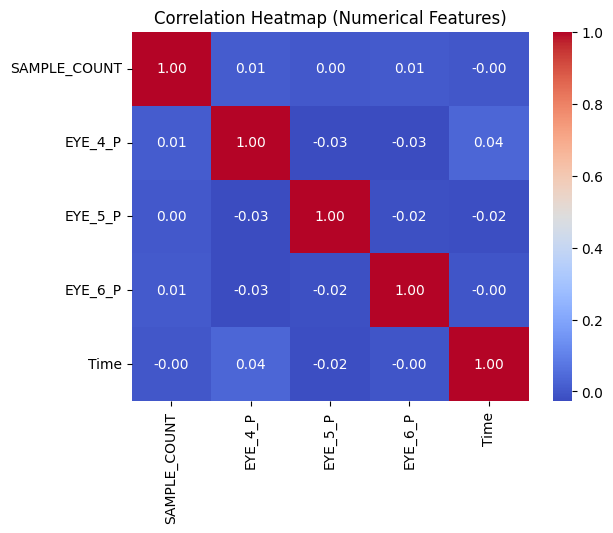

In [17]:
plt.figure()
sns.heatmap(df[['SAMPLE_COUNT', 'EYE_4_P', 'EYE_5_P', 'EYE_6_P', 'Time']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

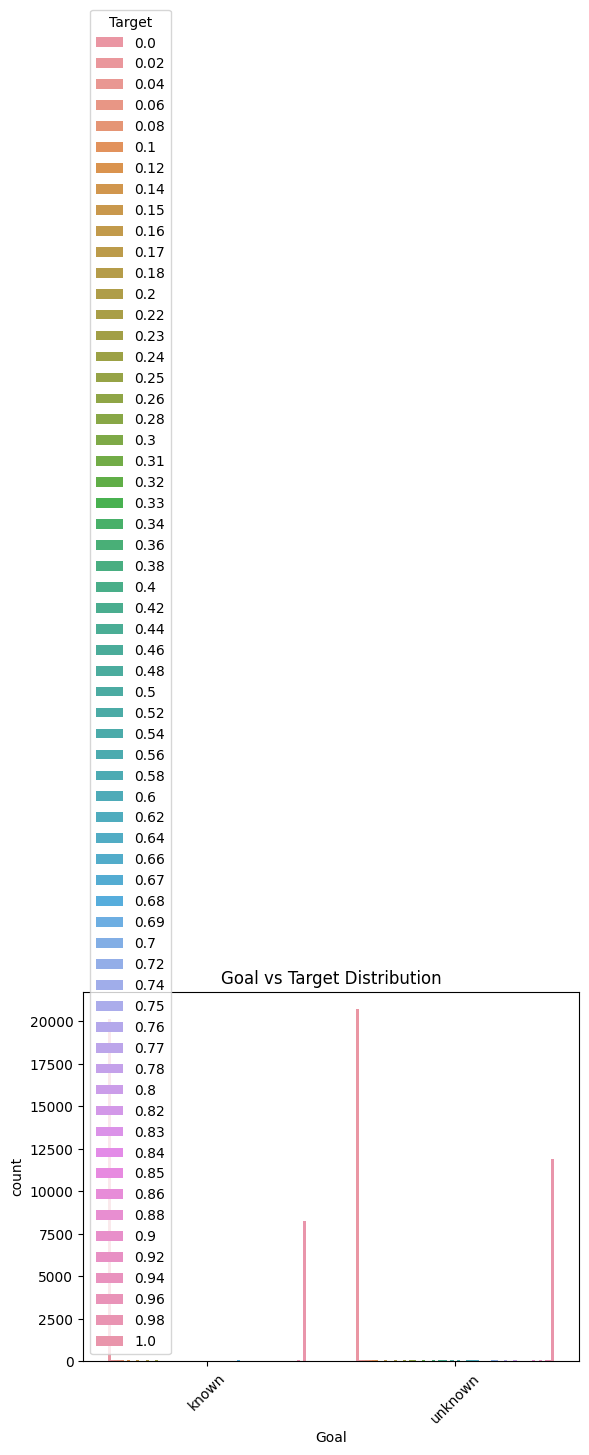

In [18]:
plt.figure()
sns.countplot(data=df, x='Goal', hue='Target')
plt.title('Goal vs Target Distribution')
plt.xticks(rotation=45)
plt.show()


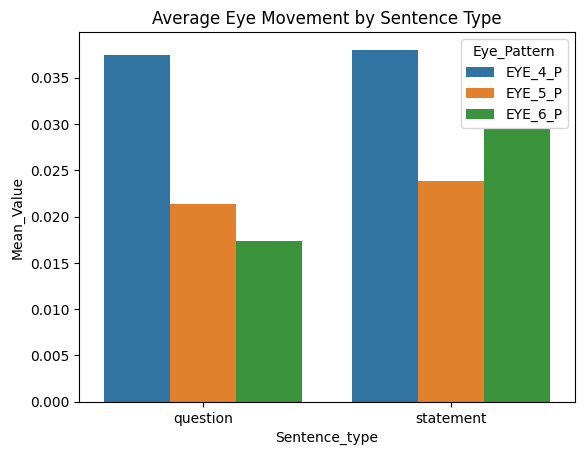

In [19]:
plt.figure()
df_grouped = df.groupby('Sentence_type')[['EYE_4_P', 'EYE_5_P', 'EYE_6_P']].mean().reset_index()
df_melted = df_grouped.melt(id_vars='Sentence_type', var_name='Eye_Pattern', value_name='Mean_Value')
sns.barplot(data=df_melted, x='Sentence_type', y='Mean_Value', hue='Eye_Pattern')
plt.title('Average Eye Movement by Sentence Type')
plt.show()

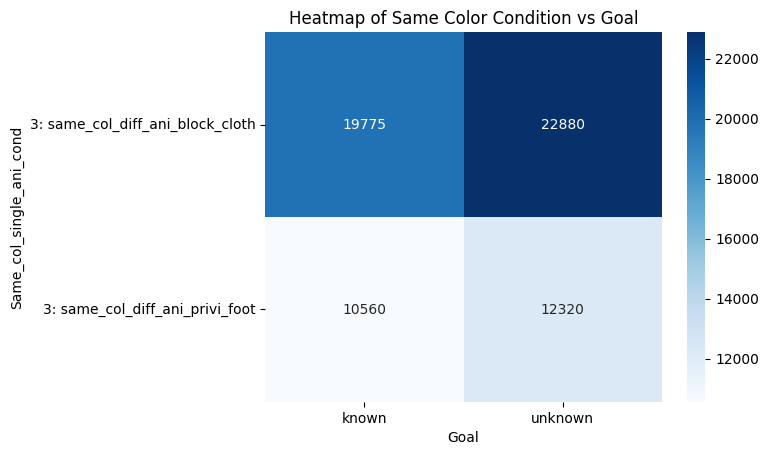

In [20]:
plt.figure()
cross_tab = pd.crosstab(df['Same_col_single_ani_cond'], df['Goal'])
sns.heatmap(cross_tab, cmap='Blues', annot=True, fmt='d')
plt.title('Heatmap of Same Color Condition vs Goal')
plt.show()


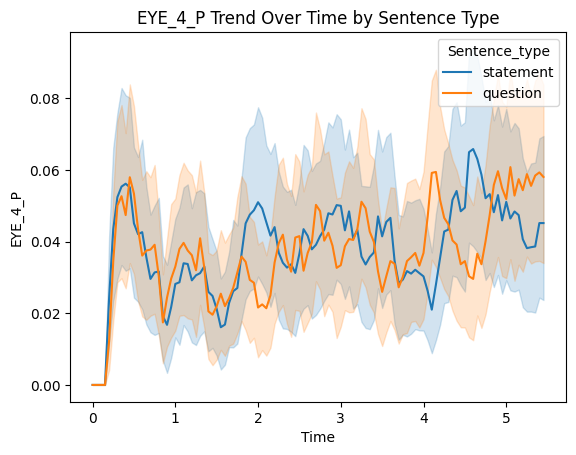

In [21]:
plt.figure()
sns.lineplot(data=df, x='Time', y='EYE_4_P', hue='Sentence_type')
plt.title('EYE_4_P Trend Over Time by Sentence Type')
plt.show()

## ML Algorithms

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [23]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [24]:
target_column = 'Goal'
X = df.drop(target_column, axis=1)
y = df[target_column]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [27]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracies[name] = round(acc, 2)


In [28]:
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy (%)'])
print(accuracy_df)

                    Model  Accuracy (%)
0     Logistic Regression         63.82
1           Decision Tree        100.00
2           Random Forest        100.00
3     K-Nearest Neighbors         98.29
4             Naive Bayes         59.79
5  Support Vector Machine         68.06
6       Gradient Boosting        100.00


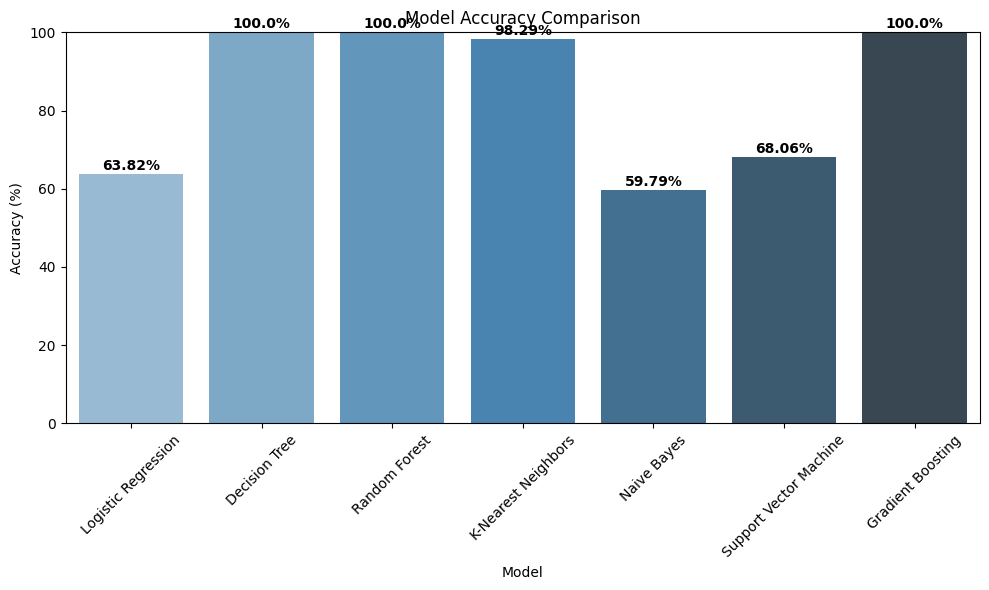

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy (%)', data=accuracy_df, palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(accuracy_df['Accuracy (%)']):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!